In [161]:
import pandas as pd


In [162]:
#Read Thomas' work
mass_balance_path = "mass_balance.csv"
df = pd.read_csv(mass_balance_path)

#Read stage-area-volume json
sav = "stage-area-volume10cm.geojson"
sav = pd.read_json(sav)
sav = pd.json_normalize(sav["features"])


In [163]:
#rename columns
df.columns=['date','elev','dz','precip(in)','precip(ft)','loss']
sav.columns=['type', 'id', 'geometry.type', 'geometry.coordinates','area_km2', 'stage_m', 'volume_km3']

#convert ft to meters
df['elev'] = df['elev'] * 0.3048
df['precip(m)'] = df['precip(ft)'] * 0.3048

#ensure numeric for join
df['elev'] = pd.to_numeric(df['elev'], errors="coerce")
sav['stage_m'] = pd.to_numeric(sav['stage_m'], errors="coerce")


In [164]:
import numpy as np

# stage-volume curve (sorted, no NaNs)
stage_volume = sav[["stage_m", "volume_km3", "area_km2"]].copy()
stage_volume["stage_m"] = pd.to_numeric(stage_volume["stage_m"], errors="coerce")
stage_volume["volume_km3"] = pd.to_numeric(stage_volume["volume_km3"], errors="coerce")
stage_volume["area_km2"] = pd.to_numeric(stage_volume["area_km2"], errors="coerce")

stage_volume = stage_volume.dropna(subset=["stage_m", "volume_km3", "area_km2"]).sort_values("stage_m")

# make sure elevations are numeric
df["elev"] = pd.to_numeric(df["elev"], errors="coerce")

# interpolate volume and area at each observed elevation
df["volume_km3"] = np.interp(
    df["elev"].to_numpy(),
    stage_volume["stage_m"].to_numpy(),
    stage_volume["volume_km3"].to_numpy()
)

df["area_km2"] = np.interp(
    df["elev"].to_numpy(),
    stage_volume["stage_m"].to_numpy(),
    stage_volume["area_km2"].to_numpy()
)


#resort by date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

#Calculate the monthly change in lake volume
df['dv'] = df['volume_km3'] - df['volume_km3'].shift(1)

In [165]:
#now lets calculate the volume of precipitation entering the lake
#Vprecip = precip * area

df['precip_m3'] = df["precip(m)"] * (df["area_km2"] * 1000000)

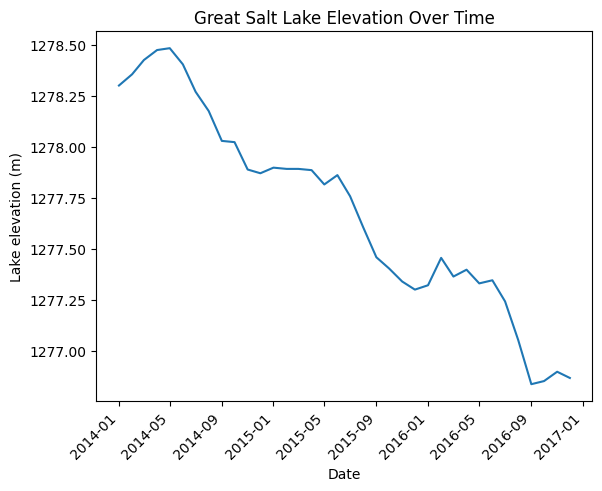

In [175]:
import matplotlib.pyplot as plt

# make sure date is datetime + sorted
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

plt.figure()
plt.plot(df["date"], df["elev"])

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Lake elevation (m)")
plt.title("Great Salt Lake Elevation Over Time")

plt.show()


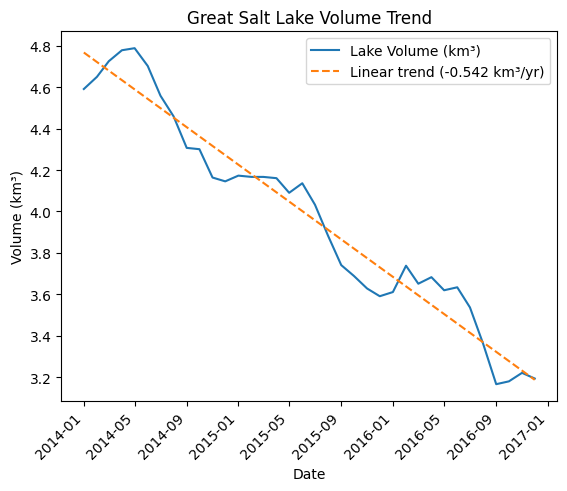

Trend rate: -0.5417 km³ per year


In [166]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# keep only rows with real date + volume
mask = df["date"].notna() & df["volume_km3"].notna()

x_fit = mdates.date2num(df.loc[mask, "date"])
y_fit = df.loc[mask, "volume_km3"].to_numpy()

# linear fit: volume vs time
m, b = np.polyfit(x_fit, y_fit, 1)

# evaluate trend for all dates
x_all = mdates.date2num(df["date"])
trend = m * x_all + b

# slope in km³ / year (m is km³ per day)
slope_year = m * 365

plt.figure()
plt.plot(df["date"], df["volume_km3"], label="Lake Volume (km³)")
plt.plot(
    df["date"],
    trend,
    linestyle="--",
    label=f"Linear trend ({slope_year:.3f} km³/yr)"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Date")
plt.ylabel("Volume (km³)")
plt.title("Great Salt Lake Volume Trend")
plt.legend()

plt.show()

print(f"Trend rate: {slope_year:.4f} km³ per year")


In [191]:
#years = (Vcurrent - Vtarget) / rate
targetft = 4170
target = targetft * 0.3048

currentft = 4192
current = currentft * 0.3048


stage_volume = sav[['stage_m','volume_km3']].sort_values('stage_m')


volume_at_current = np.interp(current, stage_volume["stage_m"], stage_volume["volume_km3"])
volume_at_target = np.interp(target ,stage_volume['stage_m'],stage_volume['volume_km3'])

print(f"Current volume at current({current}): {volume_at_current}\nVolume at target({target}): {volume_at_target}")
print(f"Difference: {volume_at_current-volume_at_target}\nRate: {slope_year}km3 per year")
print(stage_volume['stage_m'].min(), stage_volume['stage_m'].max())


rate = abs(slope_year)
years = (volume_at_current - volume_at_target) / rate
print(years," years")

Current volume at current(1277.7216): 3.9960509164530014
Volume at target(1271.016): 0.05161086418401202
Difference: 3.9444400522689893
Rate: -0.541713475745105km3 per year
1270.0 1280.0
7.281413937217589  years
